In [1]:
library(dplyr)
library(Matrix)
library(ggplot2)
options(repr.plot.width=15, repr.plot.height=8)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
in_folder = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"

In [3]:

meta1 = read.csv2(paste0(in_folder, 'meta.tab'), sep='\t')
meta2 = read.csv2(paste0(in_folder, '05_doublet_detection/meta.tab'), sep='\t')
meta3 = read.table(paste0(in_folder, "03_quality_control/meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")


In [6]:
head(meta3)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
2,cell_2,AAACCCATCAGACCTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
3,cell_3,AAACGAACAATGTTGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
4,cell_4,AAACGAACACACCAGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
5,cell_5,AAACGAAGTGATAGTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
6,cell_6,AAACGAAGTTAAGACA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive


In [15]:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
counts = readMM(paste0(main, "02_calledCells/raw_counts.mtx"))

In [102]:
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]

In [103]:
in_folder = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
meta = read.table(paste0(in_folder, "03_quality_control/meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [104]:
counts[1:10, 1:10]

10 x 10 sparse Matrix of class "dgTMatrix"
                           
 [1,] . . . .  . . .  . . .
 [2,] . . . .  . . .  . . .
 [3,] . . . .  . . .  . . .
 [4,] . . . .  . . .  . . .
 [5,] . . . .  . . .  . . .
 [6,] . . . .  . . .  . . .
 [7,] 6 2 3 8 13 3 4  7 4 3
 [8,] . 1 . .  . . 1  . . .
 [9,] . . . .  . . .  . . .
[10,] 4 7 4 6  6 2 1 10 3 6

In [105]:
split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])

In [106]:
bc_meta = data.frame(barcode = bcs, batch = samples, barcodes = barcodes)

In [107]:
meta$barcodes = paste0(meta$barcode, '-', meta$batch)
nrow(bc_meta)
bc_meta = bc_meta %>% filter(barcodes %in% meta$barcodes)
nrow(bc_meta)

[1] 48263

[1] 45281

In [111]:
bc_meta$cell = paste0('cell_', 1:nrow(bc_meta))

In [113]:
exp_design = read.csv2(paste0(main, 'experimental_design_meta_Stat3.csv'))
exp_design = exp_design[order(exp_design$Barcode),]
exp_design$batch = seq(1:nrow(exp_design))

In [114]:
head(bc_meta)
head(exp_design)

,barcode,batch,barcodes,cell
,<chr>,<chr>,<chr>,<chr>
1,AAACCCAAGATGTTCC,1,AAACCCAAGATGTTCC-1,cell_1
2,AAACCCATCAGACCTA,1,AAACCCATCAGACCTA-1,cell_2
3,AAACGAACAATGTTGC,1,AAACGAACAATGTTGC-1,cell_3
4,AAACGAACACACCAGC,1,AAACGAACACACCAGC-1,cell_4
5,AAACGAAGTGATAGTA,1,AAACGAAGTGATAGTA-1,cell_5
6,AAACGAAGTTAAGACA,1,AAACGAAGTTAAGACA-1,cell_6


,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
3,SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom,E8.5,1,SLX-21143_SITTA2_HTJH3DSX2,positive
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,2,SLX-21143_SITTA4_HTJH3DSX2,positive
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,3,SLX-21143_SITTB2_HTJH3DSX2,negative
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,4,SLX-21143_SITTB4_HTJH3DSX2,negative
11,SLX-21143,SITTC4,TTCTCGATGA-TGTCGGGCAC,MLT_4+,E8.5,5,SLX-21143_SITTC4_HTJH3DSX2,positive
12,SLX-21143,SITTD4,GCAGTATAGG-TTCCGTGCAC,MLT_4-,E8.5,6,SLX-21143_SITTD4_HTJH3DSX2,negative


In [118]:
summary(bc_meta$barcodes == meta$barcodes & bc_meta$cell == meta$cell)

   Mode    TRUE 
logical   45281 

In [133]:
head(meta %>% filter(batch==10))

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom,barcodes
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,cell_27341,AAACCCAGTCTCGGGT,E8.5,10,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative,AAACCCAGTCTCGGGT-10
2,cell_27342,AAACCCATCAACCCGG,E8.5,10,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative,AAACCCATCAACCCGG-10
3,cell_27343,AAACGCTGTGATTCAC,E8.5,10,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative,AAACGCTGTGATTCAC-10
4,cell_27344,AAACGCTGTTGCTGAT,E8.5,10,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative,AAACGCTGTTGCTGAT-10
5,cell_27345,AAACGCTTCGCCAACG,E8.5,10,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative,AAACGCTTCGCCAACG-10
6,cell_27346,AAAGGATTCCAGCAAT,E8.5,10,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative,AAAGGATTCCAGCAAT-10


In [130]:
data.frame(unique(meta$batch), unique(meta$Sample_name))

unique.meta.batch.,unique.meta.Sample_name.
<int>,<chr>
1,MLT_31+ Tom
2,MLT_3+
3,MLT_31- Tom
4,MLT_3-
5,MLT_4+
6,MLT_4-
7,MLT_L+
8,MLT_1+
9,MLT_L-


In [131]:
exp_design

,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
3,SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom,E8.5,1,SLX-21143_SITTA2_HTJH3DSX2,positive
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,2,SLX-21143_SITTA4_HTJH3DSX2,positive
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,3,SLX-21143_SITTB2_HTJH3DSX2,negative
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,4,SLX-21143_SITTB4_HTJH3DSX2,negative
11,SLX-21143,SITTC4,TTCTCGATGA-TGTCGGGCAC,MLT_4+,E8.5,5,SLX-21143_SITTC4_HTJH3DSX2,positive
12,SLX-21143,SITTD4,GCAGTATAGG-TTCCGTGCAC,MLT_4-,E8.5,6,SLX-21143_SITTD4_HTJH3DSX2,negative
13,SLX-21143,SITTD5,TGGTTCGGGT-GTGGCAGGAG,MLT_L+,E8.5,7,SLX-21143_SITTD5_HTJH3DSX2,positive
5,SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+,E8.5,8,SLX-21143_SITTE3_HTJH3DSX2,positive
14,SLX-21143,SITTE5,CGCGGTAGGT-CAGGATGTTG,MLT_L-,E8.5,9,SLX-21143_SITTE5_HTJH3DSX2,negative


In [43]:
head(bc_meta)

,barcode,batch,barcodes
,<chr>,<chr>,<chr>
1,AAACCCAAGATGTTCC,1,AAACCCAAGATGTTCC-1
2,AAACCCATCAGACCTA,1,AAACCCATCAGACCTA-1
3,AAACGAACAATGTTGC,1,AAACGAACAATGTTGC-1
4,AAACGAACACACCAGC,1,AAACGAACACACCAGC-1
5,AAACGAAGTGATAGTA,1,AAACGAAGTGATAGTA-1
6,AAACGAAGTTAAGACA,1,AAACGAAGTTAAGACA-1


In [18]:
tdtom_count = counts[nrow(counts),]
tdtom_exp = data.frame('tdtom_count' = tdtom_count, 'batch' = samples)

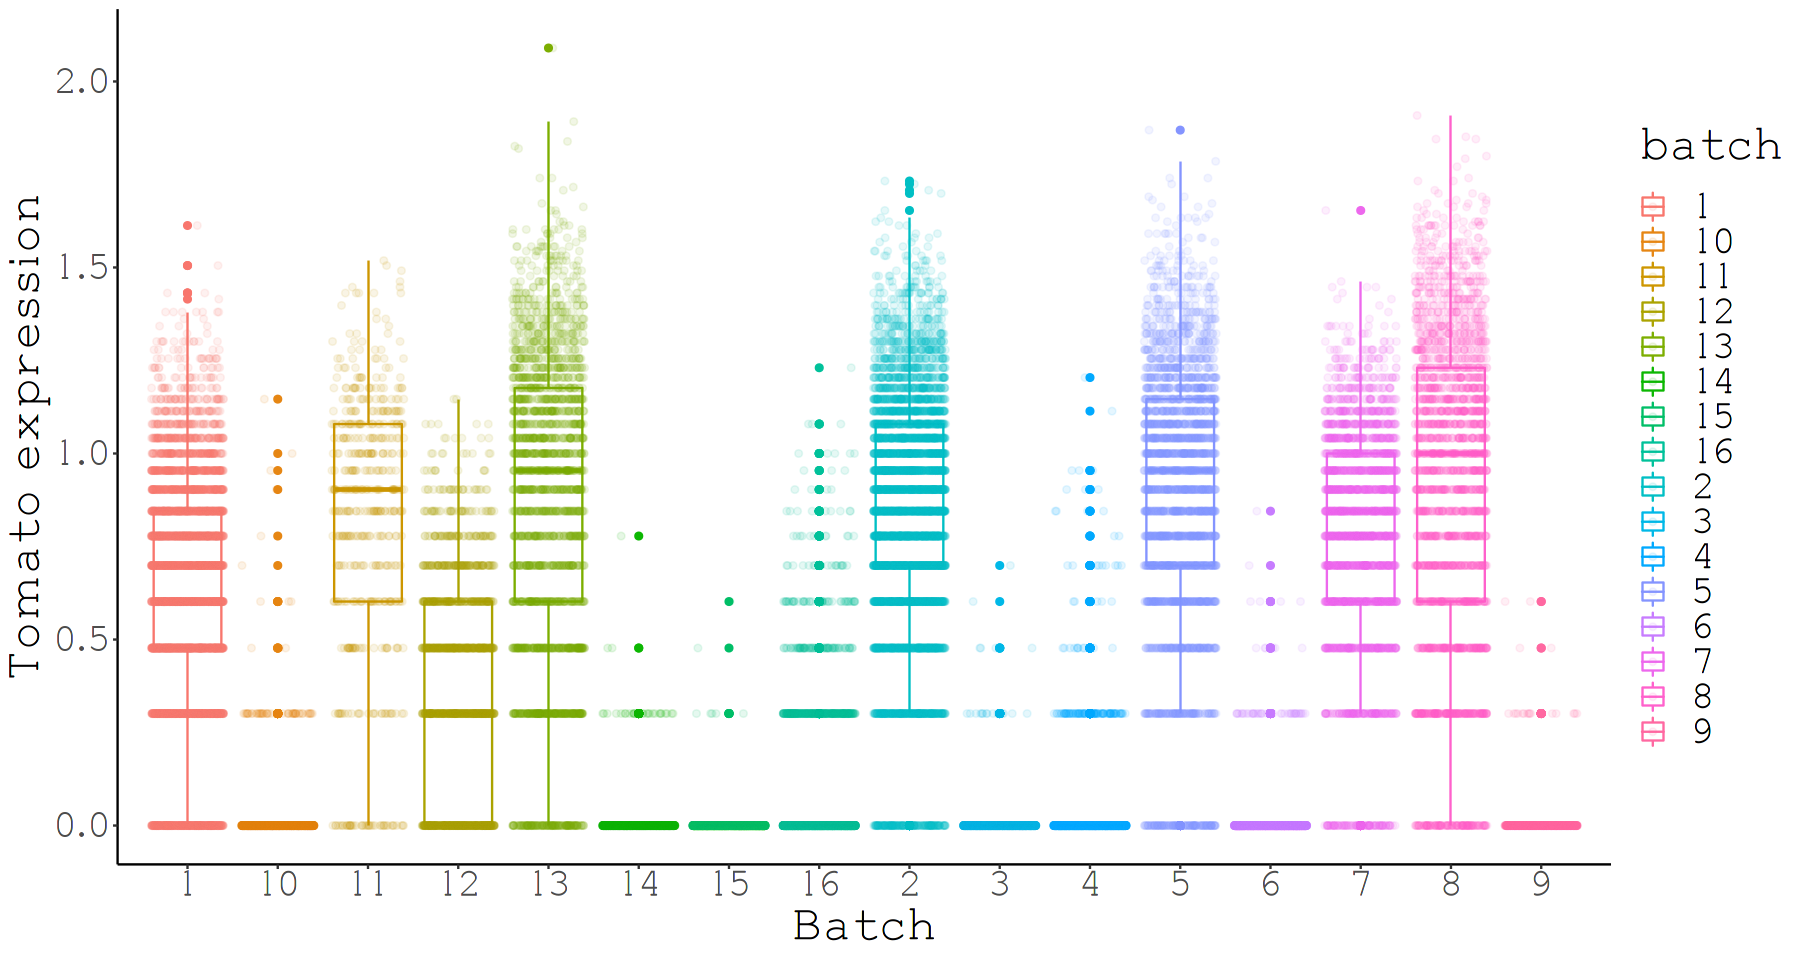

In [24]:
p6 = ggplot(tdtom_exp, aes(as.factor(batch), log10(tdtom_count+1), group=batch, colour=batch)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')
p6
## Result is as expected, will probably look better after normalisation/scaling

In [29]:
meta$barcodes = paste0(meta$barcode, '-', meta$batch)
meta = meta[meta$barcodes %in% barcodes,]

In [36]:
head(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
2,cell_2,AAACCCATCAGACCTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
3,cell_3,AAACGAACAATGTTGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
4,cell_4,AAACGAACACACCAGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
5,cell_5,AAACGAAGTGATAGTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
6,cell_6,AAACGAAGTTAAGACA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive


In [35]:
counts[meta$barcodes %in% barcodes,][1:10, 1:10]

ERROR: Error in intI(i, n = d[1], dn[[1]], give.dn = FALSE): index larger than maximal 0


In [30]:
nrow(meta)

[1] 45281

In [2]:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]


In [3]:
split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])

In [45]:
exp_design = read.csv2(paste0(main, 'experimental_design_meta_Stat3.csv'))

# Correct batch number to be in right order!
exp_design = exp_design[order(exp_design$Sample.name),]
exp_design$batch = 1:nrow(exp_design)

In [46]:
exp_design

,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
6,SLX-21143,SITTF3,GAGAGGATAT-TTGAAATGGG,MLT_1-,E8.5,1,SLX-21143_SITTF3_HTJH3DSX2,negative
5,SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+,E8.5,2,SLX-21143_SITTE3_HTJH3DSX2,positive
8,SLX-21143,SITTH3,CCCGTTCTCG-GACGGATTGG,MLT_2-,E8.5,3,SLX-21143_SITTH3_HTJH3DSX2,negative
7,SLX-21143,SITTG3,ATGACGTCGC-AGGTCAGGAT,MLT_2+,E8.5,4,SLX-21143_SITTG3_HTJH3DSX2,positive
2,SLX-21143,SITTH1,ACAATGTGAA-CGTACCGTTA,MLT_24- Tom,E8.5,5,SLX-21143_SITTH1_HTJH3DSX2,negative
1,SLX-21143,SITTG1,TGTAGTCATT-CTTGATCGTA,MLT_24+ Tom,E8.5,6,SLX-21143_SITTG1_HTJH3DSX2,positive
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,7,SLX-21143_SITTB4_HTJH3DSX2,negative
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,8,SLX-21143_SITTA4_HTJH3DSX2,positive
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,9,SLX-21143_SITTB2_HTJH3DSX2,negative


In [47]:
head(samples)

[1] "1" "1" "1" "1" "1" "1"

In [48]:
meta2 = data.frame(cell = paste0("cell_", 1:length(barcodes)),
                  barcode = bcs,
                  stage = exp_design$stage[match(samples, exp_design$batch)],
                  batch = exp_design$batch[match(samples, exp_design$batch)],
                  Sample_name = exp_design$Sample.name[match(samples, exp_design$batch)],
                  batch_name = exp_design$batch_name[match(samples, exp_design$batch)],
                  tdTom = exp_design$tdTom[match(samples, exp_design$batch)]
                )

In [27]:
exp_design = read.csv(paste0(main, 'SLX-21143_fastq/SLX-21143.HTJH3DSX2.s_1.contents.csv'))
exp_design

Pool,Barcode,Sequence,Sample.name
<chr>,<chr>,<chr>,<chr>
SLX-21143,SITTG1,TGTAGTCATT-CTTGATCGTA,MLT_24+ Tom
SLX-21143,SITTH1,ACAATGTGAA-CGTACCGTTA,MLT_24- Tom
SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom
SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom
SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+
SLX-21143,SITTF3,GAGAGGATAT-TTGAAATGGG,MLT_1-
SLX-21143,SITTG3,ATGACGTCGC-AGGTCAGGAT,MLT_2+
SLX-21143,SITTH3,CCCGTTCTCG-GACGGATTGG,MLT_2-
SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+


In [42]:
##==Open dataframe with the sample metadata/parameters==##
exp_design = exp_design[order(exp_design$Barcode),]
exp_design$stage = 'E8.5'
exp_design$batch = 1:nrow(exp_design)
exp_design$batch_name = paste0(exp_design$Pool, '_', exp_design$Barcode, '_HTJH3DSX2')
exp_design$tdTom = rep(c('positive','negative'), 8)

In [43]:
exp_design

,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
3,SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom,E8.5,1,SLX-21143_SITTA2_HTJH3DSX2,positive
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,2,SLX-21143_SITTA4_HTJH3DSX2,negative
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,3,SLX-21143_SITTB2_HTJH3DSX2,positive
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,4,SLX-21143_SITTB4_HTJH3DSX2,negative
11,SLX-21143,SITTC4,TTCTCGATGA-TGTCGGGCAC,MLT_4+,E8.5,5,SLX-21143_SITTC4_HTJH3DSX2,positive
12,SLX-21143,SITTD4,GCAGTATAGG-TTCCGTGCAC,MLT_4-,E8.5,6,SLX-21143_SITTD4_HTJH3DSX2,negative
13,SLX-21143,SITTD5,TGGTTCGGGT-GTGGCAGGAG,MLT_L+,E8.5,7,SLX-21143_SITTD5_HTJH3DSX2,positive
5,SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+,E8.5,8,SLX-21143_SITTE3_HTJH3DSX2,negative
14,SLX-21143,SITTE5,CGCGGTAGGT-CAGGATGTTG,MLT_L-,E8.5,9,SLX-21143_SITTE5_HTJH3DSX2,positive


In [36]:
exp_design[order(exp_design$Barcode),]

,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
3,SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom,E8.5,10,SLX-21143_SITTA2_HTJH3DSX2,positive
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,8,SLX-21143_SITTA4_HTJH3DSX2,positive
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,9,SLX-21143_SITTB2_HTJH3DSX2,negative
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,7,SLX-21143_SITTB4_HTJH3DSX2,negative
11,SLX-21143,SITTC4,TTCTCGATGA-TGTCGGGCAC,MLT_4+,E8.5,12,SLX-21143_SITTC4_HTJH3DSX2,positive
12,SLX-21143,SITTD4,GCAGTATAGG-TTCCGTGCAC,MLT_4-,E8.5,11,SLX-21143_SITTD4_HTJH3DSX2,negative
13,SLX-21143,SITTD5,TGGTTCGGGT-GTGGCAGGAG,MLT_L+,E8.5,14,SLX-21143_SITTD5_HTJH3DSX2,positive
5,SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+,E8.5,2,SLX-21143_SITTE3_HTJH3DSX2,positive
14,SLX-21143,SITTE5,CGCGGTAGGT-CAGGATGTTG,MLT_L-,E8.5,13,SLX-21143_SITTE5_HTJH3DSX2,negative


In [37]:
in_folder = "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/"
meta = read.table(paste0(in_folder, "03_quality_control/meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")


In [41]:
exp_design[order(exp_design$Barcode),c('batch', 'Sample.name', 'batch_name')]

,batch,Sample.name,batch_name
,<int>,<chr>,<chr>
3,10,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2
9,8,MLT_3+,SLX-21143_SITTA4_HTJH3DSX2
4,9,MLT_31- Tom,SLX-21143_SITTB2_HTJH3DSX2
10,7,MLT_3-,SLX-21143_SITTB4_HTJH3DSX2
11,12,MLT_4+,SLX-21143_SITTC4_HTJH3DSX2
12,11,MLT_4-,SLX-21143_SITTD4_HTJH3DSX2
13,14,MLT_L+,SLX-21143_SITTD5_HTJH3DSX2
5,2,MLT_1+,SLX-21143_SITTE3_HTJH3DSX2
14,13,MLT_L-,SLX-21143_SITTE5_HTJH3DSX2


In [40]:
unique(meta %>% select(batch, Sample_name, batch_name))

,batch,Sample_name,batch_name
,<int>,<chr>,<chr>
1,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2
4517,2,MLT_3+,SLX-21143_SITTA4_HTJH3DSX2
9416,3,MLT_31- Tom,SLX-21143_SITTB2_HTJH3DSX2
12505,4,MLT_3-,SLX-21143_SITTB4_HTJH3DSX2
16221,5,MLT_4+,SLX-21143_SITTC4_HTJH3DSX2
19058,6,MLT_4-,SLX-21143_SITTD4_HTJH3DSX2
22005,7,MLT_L+,SLX-21143_SITTD5_HTJH3DSX2
24480,8,MLT_1+,SLX-21143_SITTE3_HTJH3DSX2
26590,9,MLT_L-,SLX-21143_SITTE5_HTJH3DSX2


In [51]:
head(meta)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
2,cell_2,AAACCCATCAGACCTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
3,cell_3,AAACGAACAATGTTGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
4,cell_4,AAACGAACACACCAGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
5,cell_5,AAACGAAGTGATAGTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
6,cell_6,AAACGAAGTTAAGACA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive


In [50]:
head(meta2)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
2,cell_2,AAACCCATCAGACCTA,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
3,cell_3,AAACGAACAATGTTGC,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
4,cell_4,AAACGAACACACCAGC,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
5,cell_5,AAACGAAGTGATAGTA,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
6,cell_6,AAACGAAGTTAAGACA,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative


In [52]:

    meta3 = read.csv2(paste0(in_folder, 'meta.tab'), sep='\t')
        meta4 = read.csv2(paste0(in_folder, '05_doublet_detection/meta.tab'), sep='\t')

         meta5 = read.table(paste0(in_folder, "03_quality_control/meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")


In [53]:
head(meta3)
head(meta4)
head(meta5)

,cell,Sample_name,barcode,batch,batch_name,tdTom,sample,stage,doub.density,doublet,stripped,index,umap_1,umap_2,louvain_cluster
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>
1,cell_27341,MLT_1-,AAACCCAGTCTCGGGT,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,1.49073398200029,FALSE,FALSE,1,-8.62536239624023,1.30747330188751,14
2,cell_27342,MLT_1-,AAACCCATCAACCCGG,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,36.6713341836735,FALSE,FALSE,2,2.04595732688904,-1.31094622612,18
3,cell_27343,MLT_1-,AAACGCTGTGATTCAC,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,23.4350558792924,FALSE,FALSE,3,7.61345100402832,-5.03965473175049,8
4,cell_27344,MLT_1-,AAACGCTGTTGCTGAT,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,1.64740713827866,FALSE,FALSE,4,-6.8332347869873,1.47167026996613,14
5,cell_27345,MLT_1-,AAACGCTTCGCCAACG,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,1.5946847488,FALSE,FALSE,5,-7.93348932266235,1.7000834941864,14
6,cell_27346,MLT_1-,AAAGGATTCCAGCAAT,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,17.8059218224852,FALSE,FALSE,6,15.2391595840454,-2.85506176948547,16


,Sample_name,cell,barcode,batch,batch_name,tdTom,sample,stage,doub.density,doublet,stripped
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<lgl>,<lgl>
1,MLT_1-,cell_27341,AAACCCAGTCTCGGGT,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,1.49073398200029,FALSE,FALSE
2,MLT_1-,cell_27342,AAACCCATCAACCCGG,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,36.6713341836735,FALSE,FALSE
3,MLT_1-,cell_27343,AAACGCTGTGATTCAC,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,23.4350558792924,FALSE,FALSE
4,MLT_1-,cell_27344,AAACGCTGTTGCTGAT,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,1.64740713827866,FALSE,FALSE
5,MLT_1-,cell_27345,AAACGCTTCGCCAACG,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,1.5946847488,FALSE,FALSE
6,MLT_1-,cell_27346,AAAGGATTCCAGCAAT,10,SLX-21143_SITTF3_HTJH3DSX2,negative,10,E9.5,17.8059218224852,FALSE,FALSE


,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
2,cell_2,AAACCCATCAGACCTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
3,cell_3,AAACGAACAATGTTGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
4,cell_4,AAACGAACACACCAGC,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
5,cell_5,AAACGAAGTGATAGTA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
6,cell_6,AAACGAAGTTAAGACA,E8.5,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive


In [ ]:
meta3 = read.csv2(paste0(in_folder, 'meta.tab'), sep='\t')
meta4 = read.csv2(paste0(in_folder, '05_doublet_detection/meta.tab'), sep='\t')
meta5 = read.table(paste0(in_folder, "03_quality_control/meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [55]:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]


split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])
exp_design = read.csv2(paste0(main, 'experimental_design_meta_Stat3.csv'))

# Correct batch number to be in right order!
exp_design = exp_design[order(exp_design$Sample.name),]
exp_design$batch = 1:nrow(exp_design)
meta2 = data.frame(cell = paste0("cell_", 1:length(barcodes)),
                  barcode = bcs,
                  stage = exp_design$stage[match(samples, exp_design$batch)],
                  batch = exp_design$batch[match(samples, exp_design$batch)],
                  Sample_name = exp_design$Sample.name[match(samples, exp_design$batch)],
                  batch_name = exp_design$batch_name[match(samples, exp_design$batch)],
                  tdTom = exp_design$tdTom[match(samples, exp_design$batch)]
                )

In [56]:
head(meta2)

,cell,barcode,stage,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
2,cell_2,AAACCCATCAGACCTA,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
3,cell_3,AAACGAACAATGTTGC,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
4,cell_4,AAACGAACACACCAGC,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
5,cell_5,AAACGAAGTGATAGTA,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
6,cell_6,AAACGAAGTTAAGACA,E8.5,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative


In [10]:
exp_design = read.csv(paste0(main, 'SLX-21143_fastq/SLX-21143.HTJH3DSX2.s_1.contents.csv'))
exp_design = exp_design[order(exp_design$Barcode),]

In [11]:
##==Open dataframe with the sample metadata/parameters==##
exp_design$stage = 'E8.5'
exp_design$batch = 1:nrow(exp_design)
exp_design$batch_name = paste0(exp_design$Pool, '_', exp_design$Barcode, '_HTJH3DSX2')
exp_design$tdTom = rep(c('positive','negative'), 8)

In [12]:
exp_design

,Pool,Barcode,Sequence,Sample.name,stage,batch,batch_name,tdTom
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
3,SLX-21143,SITTA2,GTGGATCAAA-GCCAACCCTG,MLT_31+ Tom,E8.5,1,SLX-21143_SITTA2_HTJH3DSX2,positive
9,SLX-21143,SITTA4,CTCTAGCGAG-TATCTTCATC,MLT_3+,E8.5,2,SLX-21143_SITTA4_HTJH3DSX2,negative
4,SLX-21143,SITTB2,TCTACCATTT-CGGGAGAGTC,MLT_31- Tom,E8.5,3,SLX-21143_SITTB2_HTJH3DSX2,positive
10,SLX-21143,SITTB4,GTAGACGAAA-CTAGTGTGGT,MLT_3-,E8.5,4,SLX-21143_SITTB4_HTJH3DSX2,negative
11,SLX-21143,SITTC4,TTCTCGATGA-TGTCGGGCAC,MLT_4+,E8.5,5,SLX-21143_SITTC4_HTJH3DSX2,positive
12,SLX-21143,SITTD4,GCAGTATAGG-TTCCGTGCAC,MLT_4-,E8.5,6,SLX-21143_SITTD4_HTJH3DSX2,negative
13,SLX-21143,SITTD5,TGGTTCGGGT-GTGGCAGGAG,MLT_L+,E8.5,7,SLX-21143_SITTD5_HTJH3DSX2,positive
5,SLX-21143,SITTE3,ACCAGACAAC-AGGAACTAGG,MLT_1+,E8.5,8,SLX-21143_SITTE3_HTJH3DSX2,negative
14,SLX-21143,SITTE5,CGCGGTAGGT-CAGGATGTTG,MLT_L-,E8.5,9,SLX-21143_SITTE5_HTJH3DSX2,positive


In [75]:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]


split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])
exp_design = read.csv2(paste0(main, 'experimental_design_meta_Stat3.csv'))

# Correct batch number to be in right order!
exp_design = exp_design[order(exp_design$Sample.name),]
exp_design$batch = 1:nrow(exp_design)

In [76]:
meta2 = data.frame(cell = paste0("cell_", 1:length(barcodes)),
                  barcode = bcs,
                  stage = exp_design$stage[match(samples, exp_design$batch)],
                  batch = exp_design$batch[match(samples, exp_design$batch)],
                  Sample_name = exp_design$Sample.name[match(samples, exp_design$batch)],
                  batch_name = exp_design$batch_name[match(samples, exp_design$batch)],
                  tdTom = exp_design$tdTom[match(samples, exp_design$batch)]
                )
meta2$stage = NULL
                 
head(meta2)

,cell,barcode,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
2,cell_2,AAACCCATCAGACCTA,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
3,cell_3,AAACGAACAATGTTGC,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
4,cell_4,AAACGAACACACCAGC,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
5,cell_5,AAACGAAGTGATAGTA,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative
6,cell_6,AAACGAAGTTAAGACA,1,MLT_1-,SLX-21143_SITTF3_HTJH3DSX2,negative


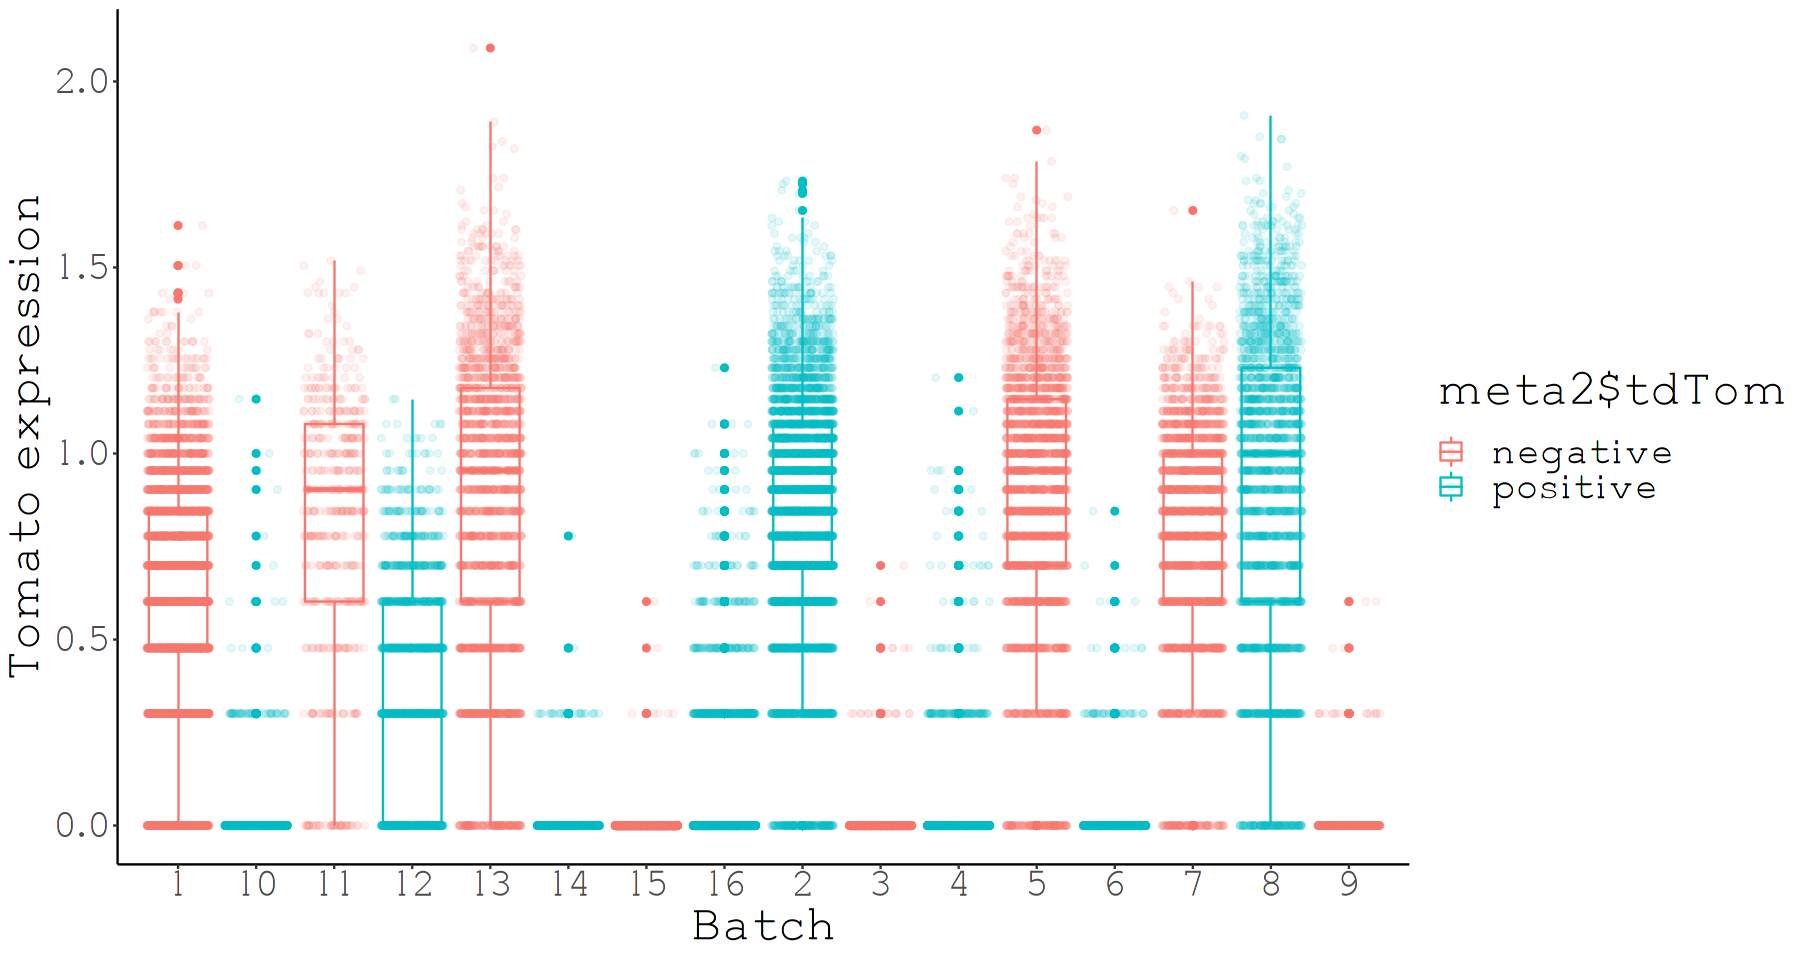

In [79]:
p6 = ggplot(tdtom_exp, aes(as.factor(batch), log10(tdtom_count+1), group=batch, colour=meta2$tdTom)) + 
    geom_boxplot() +
    geom_point(position = position_jitterdodge(jitter.width =0.8), alpha=0.1) +
    theme_classic() + 
    theme(text = element_text(size=30)) + 
    xlab('Batch') + ylab('Tomato expression')
p6
## Result is as expected, will probably look better after normalisation/scaling

In [78]:
nrow(meta2)

[1] 48263

In [77]:
nrow(tdtom_exp)

[1] 48263

In [123]:
main = '/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/'
barcodes = read.table(paste0(main, "02_calledCells/barcodes.tsv"), stringsAsFactors = F)[,1]


split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])
                 
exp_design = read.csv2(paste0(main, 'experimental_design_meta_Stat3.csv'))

# Correct batch number to be in right order!
exp_design = exp_design[order(exp_design$Barcode),]
exp_design$batch = 1:nrow(exp_design)
meta2 = data.frame(cell = paste0("cell_", 1:length(barcodes)),
                  barcode = bcs,
                  stage = exp_design$stage[match(samples, exp_design$batch)],
                  batch = exp_design$batch[match(samples, exp_design$batch)],
                  Sample_name = exp_design$Sample.name[match(samples, exp_design$batch)],
                  batch_name = exp_design$batch_name[match(samples, exp_design$batch)],
                  tdTom = exp_design$tdTom[match(samples, exp_design$batch)]
                )
meta2$stage = NULL

                 
# stages = data.frame('Sample_name' = c('24+ Tom', '24- Tom', '31+ Tom', '31- Tom', '1+', '1-', '2+', '2-', '3+', '3-', '4+', '4-', 'L+', 'L-', 'S+', 'S-'),
# 'stage' = c(rep('E8.5', 4), rep('E9.5', 8), rep('E7.5', 4)))
# stages$Sample_name = paste0('MLT_', stages$Sample_name)
# meta2 = merge(meta2, stages, by='Sample_name')


In [124]:
head(meta2)

,cell,barcode,batch,Sample_name,batch_name,tdTom
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,cell_1,AAACCCAAGATGTTCC,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
2,cell_2,AAACCCATCAGACCTA,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
3,cell_3,AAACGAACAATGTTGC,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
4,cell_4,AAACGAACACACCAGC,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
5,cell_5,AAACGAAGTGATAGTA,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
6,cell_6,AAACGAAGTTAAGACA,1,MLT_31+ Tom,SLX-21143_SITTA2_HTJH3DSX2,positive
